# Bronx and Queens Modeling

## Import Packages

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [121]:
# Directories
DATA_DIR = Path("../../scr/data")  # updated relative path
FIG_DIR  = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Time series CV settings
N_SPLITS  = 26
TEST_SIZE = 14
MIN_TRAIN = 365

# Define functions for metrics
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2)))

def mape_safe(y_true, y_pred):
    y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
    mask = y_true != 0
    if mask.sum() < len(y_true) * 0.5:
        return np.nan
    return float(np.mean(np.abs(y_true[mask] - y_pred[mask]) / y_true[mask]) * 100)

In [122]:
# Make a function which prepares a dataframe for SARIMAX

def make_sarima_series(df):
    s = df.set_index("ds")["count"]
    s = s.reindex(pd.date_range(s.index.min(), s.index.max(), freq="D"), fill_value=0)
    s.index.freq = pd.tseries.frequencies.to_offset("D")
    return s

## Load Data

In [98]:
rats_raw = pd.read_csv(DATA_DIR / "rat_sightings_data" / "Rat_Sightings_NYC.csv")

In [99]:
# # Rodent inspections (combine 50 files)
# insp_list = []
# for i in range(1, 51):
#     file_path = DATA_DIR / "split_up_rat_inspection_data" / f"rodent_inspection_{i}.csv"
#     try:
#         df = pd.read_csv(file_path)
#         insp_list.append(df)
#     except FileNotFoundError:
#         print(f"missing file: {file_path}")

# insp_raw = pd.concat(insp_list, ignore_index=True)

## Prepare the Data

In [100]:
# Cell 3 – clean rat sightings
def clean_rats(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df["created_dt"] = pd.to_datetime(df["Created Date"], errors="coerce")
    df["zip_clean"]  = df["Incident Zip"].astype(str).str.strip().str.extract(r"(\d{5})")[0]
    df["borough"]    = (
        df["Borough"].astype(str).str.upper().str.strip()
        .replace({"THE BRONX": "BRONX", "STATEN IS": "STATEN ISLAND", "NAN": pd.NA, "0": pd.NA})
    )
    df["week"] = df["created_dt"].dt.to_period("W-SUN").dt.start_time
    df = df.dropna(subset=["created_dt", "zip_clean"])
    df = df[df["created_dt"] >= "2020-01-01"].reset_index(drop=True)
    return df

rats = clean_rats(rats_raw)
print(f"Rat Sightings: {len(rats):,} rows")
print(rats["borough"].value_counts())

Rat Sightings: 140,315 rows
borough
BROOKLYN         54032
MANHATTAN        36847
QUEENS           22792
BRONX            22603
STATEN ISLAND     4030
UNSPECIFIED          9
Name: count, dtype: int64


In [101]:
DATA_CUTOFF = pd.Timestamp("2025-02-28")
print(f"data cutoff: {DATA_CUTOFF.date()}")

def build_daily(df, borough):
    sub = (
        df[df["borough"] == borough]
        .dropna(subset=["created_dt"])
        .groupby(df["created_dt"].dt.date)
        .size()
        .reset_index()
    )
    sub.columns = ["ds", "count"]
    sub["ds"] = pd.to_datetime(sub["ds"])
    sub = sub[sub["ds"] <= DATA_CUTOFF].sort_values("ds")

    if len(sub) == 0:
        print(f"no data for {borough}")
        return None

    full = pd.date_range(sub["ds"].min(), sub["ds"].max(), freq="D")
    sub = sub.set_index("ds").reindex(full, fill_value=0).rename_axis("ds").reset_index()
    return sub

daily_bronx  = build_daily(rats, "BRONX")
daily_queens = build_daily(rats, "QUEENS")

for name, d in [("Bronx", daily_bronx), ("Queens", daily_queens)]:
    print(f"\n{name}: {len(d)} days, mean={d['count'].mean():.1f}, peak={d['count'].max()}")

data cutoff: 2025-02-28

Bronx: 1886 days, mean=10.2, peak=31

Queens: 1886 days, mean=10.4, peak=38


# Plot Daily Rat Sightings

I don't know why this is needed...

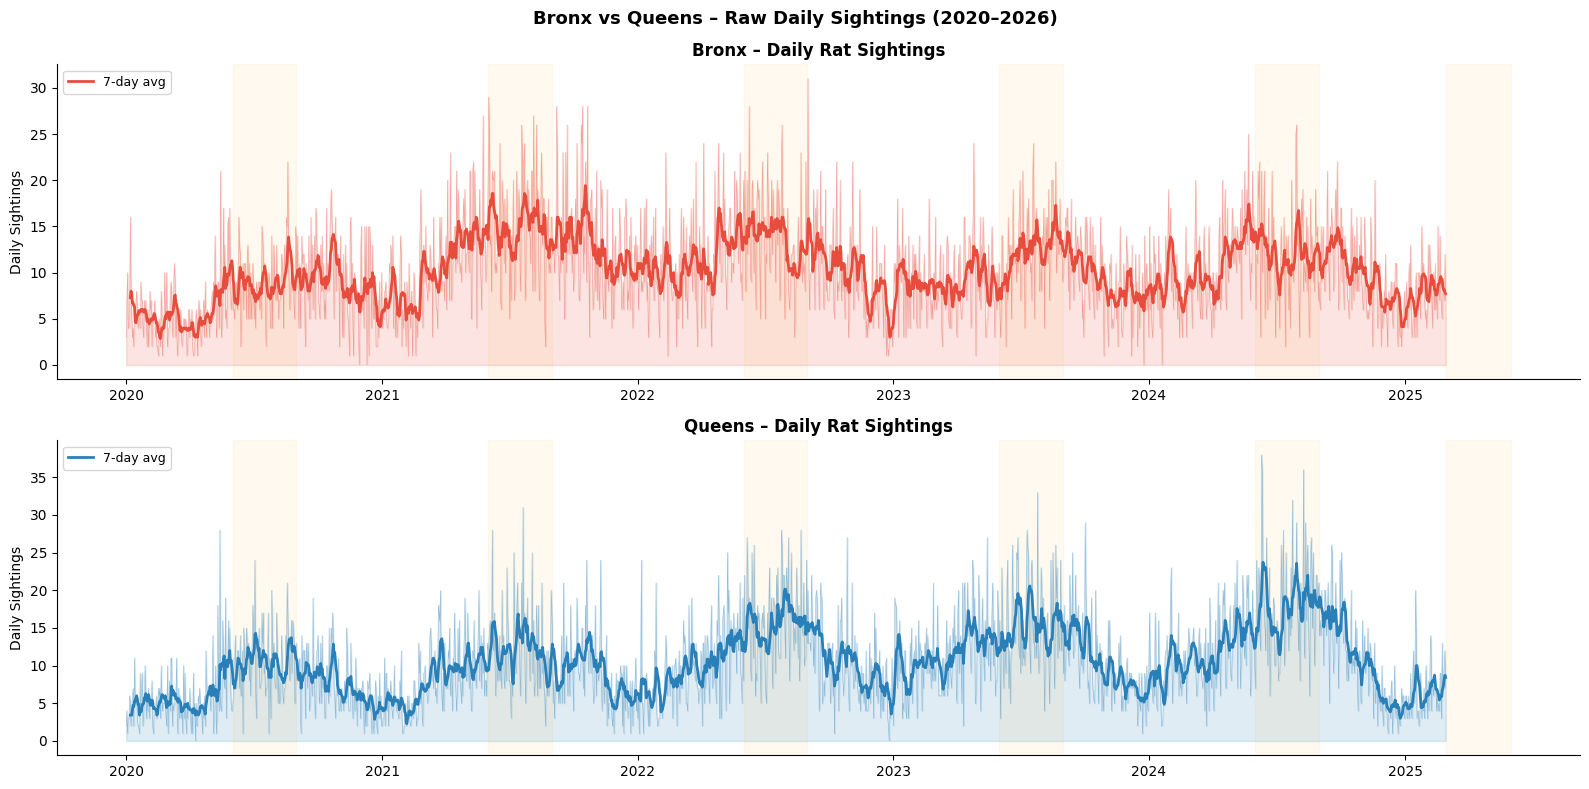

In [102]:
# Cell 9 – plot raw daily series
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

for ax, d, name, color in zip(axes,
                               [daily_bronx, daily_queens],
                               ["Bronx", "Queens"],
                               ["#e74c3c", "#2980b9"]):
    roll7 = d.set_index("ds")["count"].rolling(7).mean()
    ax.fill_between(d["ds"], d["count"], alpha=0.15, color=color)
    ax.plot(d["ds"], d["count"], color=color, lw=0.4, alpha=0.4)
    ax.plot(roll7.index, roll7.values, color=color, lw=2, label="7-day avg")

    for yr in range(2020, DATA_CUTOFF.year + 1):
        ax.axvspan(pd.Timestamp(f"{yr}-06-01"),
                   min(pd.Timestamp(f"{yr}-08-31"), DATA_CUTOFF),
                   alpha=0.06, color="orange")

    ax.set_title(f"{name} – Daily Rat Sightings", fontweight="bold")
    ax.set_ylabel("Daily Sightings")
    ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Bronx vs Queens – Raw Daily Sightings (2020–2026)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_raw_daily.png", dpi=150, bbox_inches="tight")
plt.show()

# First Look at Prophet Model on Both Boroughs

Why did we pick the changepoint prior scals and such this way?

In [103]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def prophet_walkforward(daily_df, borough):
    tscv    = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)
    records = []

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(daily_df)):
        
        train = daily_df.iloc[tr_idx].copy()
        test  = daily_df.iloc[te_idx].copy()

        m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, seasonality_mode="additive", changepoint_prior_scale=0.05, interval_width=0.80)
        m.add_country_holidays(country_name="US")

        # fit the model
        m.fit(train.rename(columns={"count": "y"}))

        # have the model make a TEST_SIZE length forecast
        future   = m.make_future_dataframe(periods=TEST_SIZE, freq="D")
        forecast = m.predict(future)
        
        # get the actual forecasts -- this is due to how Prophet's make_future_dataframe functions
        forecast["yhat"] = forecast["yhat"].clip(lower=0)


        
        fc     = forecast.set_index("ds")["yhat"].reindex(pd.DatetimeIndex(test["ds"]), fill_value=0)
        actual = test.set_index("ds")["count"].reindex(fc.index, fill_value=0)


        records.append({"borough": borough, "fold": fold + 1, 
                        "test_start": test["ds"].min().date(),
                        "test_end": test["ds"].max().date(), 
                        "MAE": round(mean_absolute_error(actual, fc), 2), 
                        "RMSE": round(rmse(actual, fc), 2),})

    df = pd.DataFrame(records)

    # Compute overall metrics
    overall = pd.DataFrame([{"borough": borough, "fold": "overall", "test_start": pd.NaT, 
                             "test_end": pd.NaT, "MAE": f"{df['MAE'].mean():.2f} ± {df['MAE'].std():.2f}", 
                             "RMSE": f"{df['RMSE'].mean():.2f} ± {df['RMSE'].std():.2f}"}])

    return pd.concat([df, overall], ignore_index=True)

# Example usage
wf_bronx  = prophet_walkforward(daily_bronx,  "Bronx")
wf_queens = prophet_walkforward(daily_queens, "Queens")

# Combine both boroughs into a single DataFrame for display
wf_all = pd.concat([wf_bronx, wf_queens], ignore_index=True)
wf_all

01:02:26 - cmdstanpy - INFO - Chain [1] start processing
01:02:26 - cmdstanpy - INFO - Chain [1] done processing
01:02:26 - cmdstanpy - INFO - Chain [1] start processing
01:02:26 - cmdstanpy - INFO - Chain [1] done processing
01:02:27 - cmdstanpy - INFO - Chain [1] start processing
01:02:27 - cmdstanpy - INFO - Chain [1] done processing
01:02:27 - cmdstanpy - INFO - Chain [1] start processing
01:02:27 - cmdstanpy - INFO - Chain [1] done processing
01:02:28 - cmdstanpy - INFO - Chain [1] start processing
01:02:28 - cmdstanpy - INFO - Chain [1] done processing
01:02:28 - cmdstanpy - INFO - Chain [1] start processing
01:02:29 - cmdstanpy - INFO - Chain [1] done processing
01:02:29 - cmdstanpy - INFO - Chain [1] start processing
01:02:29 - cmdstanpy - INFO - Chain [1] done processing
01:02:30 - cmdstanpy - INFO - Chain [1] start processing
01:02:30 - cmdstanpy - INFO - Chain [1] done processing
01:02:30 - cmdstanpy - INFO - Chain [1] start processing
01:02:30 - cmdstanpy - INFO - Chain [1]

,borough,fold,test_start,test_end,MAE,RMSE
0,Bronx,1,2024-03-02,2024-03-15,3.19,4.19
1,Bronx,2,2024-03-16,2024-03-29,2.81,3.36
2,Bronx,3,2024-03-30,2024-04-12,2.62,3.18
3,Bronx,4,2024-04-13,2024-04-26,3.12,4.1
4,Bronx,5,2024-04-27,2024-05-10,2.39,2.63
5,Bronx,6,2024-05-11,2024-05-24,4.57,5.76
6,Bronx,7,2024-05-25,2024-06-07,3.49,4.19
7,Bronx,8,2024-06-08,2024-06-21,3.45,4.18
8,Bronx,9,2024-06-22,2024-07-05,3.27,4.12
9,Bronx,10,2024-07-06,2024-07-19,3.2,4.04


# Testing SARIMA, XGBoost, Ridge, and Ensemble Model

In [131]:
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

In [132]:
def make_features(series):
    df = pd.DataFrame({"y": series})
    df["lag14"]     = df["y"].shift(14)
    df["lag15"]     = df["y"].shift(15)
    df["roll7"]     = df["y"].shift(14).rolling(7,  min_periods=1).mean()
    df["roll14"]    = df["y"].shift(14).rolling(14, min_periods=1).mean()
    df["dow"]       = df.index.dayofweek
    df["month"]     = df.index.month
    df["is_summer"] = df["month"].isin([6,7,8]).astype(int)
    df["is_winter"] = df["month"].isin([12,1,2]).astype(int)
    df = df.dropna()
    return df.drop(columns="y"), df["y"].values

In [153]:
def all_models_walkforward(daily_df, borough):
    tscv    = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)
    records = []

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(daily_df)):
        train  = daily_df.iloc[tr_idx].copy()
        test   = daily_df.iloc[te_idx].copy()

        actual   = test["count"].values
        fold_rec = {"borough": borough, "fold": fold+1, "test_start": test["ds"].min().date()}

        # Prophet
        try:
            m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, 
                        seasonality_mode="additive", changepoint_prior_scale=0.05, interval_width=0.80)
            m.add_country_holidays(country_name="US")
            m.fit(train.rename(columns={"count":"y"}))
            future = m.make_future_dataframe(periods=TEST_SIZE, freq="D")
            forecast = m.predict(future)
            fc_prophet = np.clip(forecast.set_index("ds")["yhat"].reindex(pd.DatetimeIndex(test["ds"]), fill_value=0).values, 0, None)
        except:
            fc_prophet = np.full(TEST_SIZE, train["count"].mean())

        # SARIMA
        try:
            s_train  = make_sarima_series(train)
            s_fit    = SARIMAX(s_train, order=(1,1,1), seasonal_order=(1,1,1,7), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            fc_sarima = np.clip(s_fit.forecast(steps=TEST_SIZE).values, 0, None)
        except:
            fc_sarima = np.full(TEST_SIZE, train["count"].mean())

        # XGBoost
        try:
            s_tr = make_sarima_series(train)
            X_tr, y_tr = make_features(s_tr)
            xgb_m = xgb.XGBRegressor(n_estimators=25,learning_rate=0.1,max_depth=5,
                                     subsample=0.8,colsample_bytree=0.8,min_child_weight=3,gamma=0.1,
                                     reg_alpha=0.1,reg_lambda=1.0,random_state=42,verbosity=0)
            xgb_m.fit(X_tr, y_tr)

            combined = pd.concat([train, test]).reset_index(drop=True)
            s_full   = make_sarima_series(combined)
            X_full, _ = make_features(s_full)
            fc_xgb = np.clip(xgb_m.predict(X_full.tail(TEST_SIZE)), 0, None)
        except:
            fc_xgb = np.full(TEST_SIZE, train["count"].mean())

        # Ridge
        try:
            s_tr = make_sarima_series(train)
            X_tr, y_tr = make_features(s_tr)
            scaler  = StandardScaler()
            ridge   = Ridge(alpha=1.0)
            ridge.fit(scaler.fit_transform(X_tr), y_tr)
            combined = pd.concat([train, test]).reset_index(drop=True)
            s_full   = make_sarima_series(combined)
            X_full, _ = make_features(s_full)
            fc_ridge  = np.clip(ridge.predict(scaler.transform(X_full.tail(TEST_SIZE))), 0, None)
        except:
            fc_ridge = np.full(TEST_SIZE, train["count"].mean())

        # Ensemble
        fc_ensemble = (fc_prophet + fc_sarima + fc_xgb + fc_ridge) / 4

        # Compute MAE for each model. 
        # We make sure to forecasts to nearests integer.
        for label, fc in [("Prophet", fc_prophet), ("SARIMA", fc_sarima), ("XGBoost", fc_xgb), ("Ridge", fc_ridge), ("Ensemble", fc_ensemble)]:
            fc_eval = np.rint(fc[:len(actual)])
            # MAE
            fold_rec[f"MAE_{label}"] = round(mean_absolute_error(actual, fc_eval), 2)
            # RMSE
            fold_rec[f"RMSE_{label}"] = round(np.sqrt(mean_squared_error(actual, fc_eval)), 2)

        records.append(fold_rec)

    df_folds = pd.DataFrame(records)

    # Compute overall mean ± std for each model
    metric_cols = [c for c in df_folds.columns if c.startswith(("MAE_", "RMSE_"))]

    overall = pd.DataFrame([{
        "borough": borough,
        "fold": "overall",
        "test_start": pd.NaT,
        **{
            col: f"{df_folds[col].mean():.2f}" # ± {df_folds[col].std():.2f} was originally included for some reason
            for col in metric_cols
        }
    }])

    return pd.concat([df_folds, overall], ignore_index=True)

# Example usage
wf_multi_bronx  = all_models_walkforward(daily_bronx,  "Bronx")
wf_multi_queens = all_models_walkforward(daily_queens, "Queens")

# Combine into a single DataFrame for display
wf_multi_all = pd.concat([wf_multi_bronx, wf_multi_queens], ignore_index=True)
wf_multi_all

02:21:15 - cmdstanpy - INFO - Chain [1] start processing
02:21:15 - cmdstanpy - INFO - Chain [1] done processing
02:21:19 - cmdstanpy - INFO - Chain [1] start processing
02:21:19 - cmdstanpy - INFO - Chain [1] done processing
02:21:24 - cmdstanpy - INFO - Chain [1] start processing
02:21:24 - cmdstanpy - INFO - Chain [1] done processing
02:21:28 - cmdstanpy - INFO - Chain [1] start processing
02:21:28 - cmdstanpy - INFO - Chain [1] done processing
02:21:32 - cmdstanpy - INFO - Chain [1] start processing
02:21:32 - cmdstanpy - INFO - Chain [1] done processing
02:21:36 - cmdstanpy - INFO - Chain [1] start processing
02:21:36 - cmdstanpy - INFO - Chain [1] done processing
02:21:41 - cmdstanpy - INFO - Chain [1] start processing
02:21:41 - cmdstanpy - INFO - Chain [1] done processing
02:21:45 - cmdstanpy - INFO - Chain [1] start processing
02:21:45 - cmdstanpy - INFO - Chain [1] done processing
02:21:50 - cmdstanpy - INFO - Chain [1] start processing
02:21:50 - cmdstanpy - INFO - Chain [1]

,borough,fold,test_start,MAE_Prophet,RMSE_Prophet,MAE_SARIMA,RMSE_SARIMA,MAE_XGBoost,RMSE_XGBoost,MAE_Ridge,RMSE_Ridge,MAE_Ensemble,RMSE_Ensemble
0,Bronx,1,2024-03-02,3.07,4.08,3.07,4.25,3.14,4.05,3.14,4.12,3.14,4.12
1,Bronx,2,2024-03-16,2.79,3.37,2.71,3.12,2.71,3.07,2.86,3.38,2.79,3.2
2,Bronx,3,2024-03-30,2.5,3.15,2.64,3.35,3.43,3.93,3.43,4.02,2.93,3.54
3,Bronx,4,2024-04-13,3.21,4.27,3.64,4.95,3.43,4.97,3.57,4.93,3.36,4.67
4,Bronx,5,2024-04-27,2.43,2.65,2.79,3.15,2.57,3.21,2.21,2.87,2.5,2.94
5,Bronx,6,2024-05-11,4.5,5.75,4.14,5.35,4.29,4.99,4.21,5.39,4.21,5.27
6,Bronx,7,2024-05-25,3.57,4.24,3.43,4.17,3.64,4.28,3.79,4.38,3.43,4.09
7,Bronx,8,2024-06-08,3.5,4.3,4.57,5.33,3.93,4.74,4.36,5.12,4.07,4.79
8,Bronx,9,2024-06-22,3.29,4.14,3.43,4.12,3.79,4.57,3.79,4.33,3.57,4.19
9,Bronx,10,2024-07-06,3.21,3.97,2.57,3.21,2.86,3.21,2.79,3.43,2.79,3.37


# Bar Chart Comparing RMSEs and MAEs

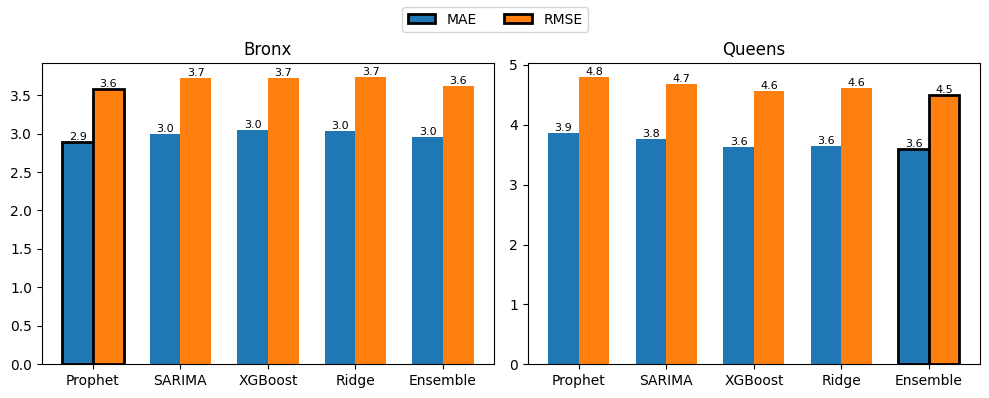

In [154]:
fig,axes=plt.subplots(1,2,figsize=(10,4))
models=["Prophet","SARIMA","XGBoost","Ridge","Ensemble"]

for ax,df,name in zip(axes,[wf_multi_bronx,wf_multi_queens],["Bronx","Queens"]):
    df=df[df["fold"]!="overall"]
    mae=[df[f"MAE_{m}"].mean() for m in models]
    rmse=[df[f"RMSE_{m}"].mean() for m in models]
    x=np.arange(len(models)); w=0.35

    b1=ax.bar(x-w/2,mae,w,label="MAE")
    b2=ax.bar(x+w/2,rmse,w,label="RMSE")

    b1[np.argmin(mae)].set_edgecolor("black"); b1[np.argmin(mae)].set_linewidth(2)
    b2[np.argmin(rmse)].set_edgecolor("black"); b2[np.argmin(rmse)].set_linewidth(2)

    for bars in (b1,b2):
        for bar in bars:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height(),
                    f"{bar.get_height():.1f}",
                    ha="center",va="bottom",fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(models)
    ax.set_title(name)

# One shared legend
fig.legend(["MAE","RMSE"], loc="upper center", ncol=2)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.savefig(FIG_DIR/"02c_model_comparison.png",dpi=150,bbox_inches="tight")
plt.show()

For the Bronx, the ensemble model and prophet model perform essentially the same. Meanwhile, for queens, the ensemble model performs better, but not by very wide margin.

# Final Fitting of Prophet Model to Entire Data

In [ ]:
# We need to load the data one more time for the final fit.

rats_raw = pd.read_csv(DATA_DIR / "rat_sightings_data" / "Rat_Sightings_NYC.csv")
rats = clean_rats(rats_raw)

daily_bronx  = build_daily(rats, "BRONX")
daily_queens = build_daily(rats, "QUEENS")


In [ ]:
# Cell 12 – fit final Prophet on full data, get 14-day forecast
FORECAST_DAYS = 14

def fit_final_prophet(daily_df, borough):
    train = daily_df.copy()
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                daily_seasonality=False, seasonality_mode="additive",
                changepoint_prior_scale=0.05, interval_width=0.80)
    m.add_country_holidays(country_name="US")
    m.fit(train.rename(columns={"count":"y"}))

    future   = m.make_future_dataframe(periods=FORECAST_DAYS, freq="D")
    forecast = m.predict(future)
    forecast["yhat"]       = forecast["yhat"].clip(lower=0)
    forecast["yhat_lower"] = forecast["yhat_lower"].clip(lower=0)

    fc_future = forecast[forecast["ds"] > DATA_CUTOFF].copy()
    print(f"{borough}: {len(train)} training days")
    return m, fc_future, forecast

m_bronx,  fc_bronx,  full_fc_bronx  = fit_final_prophet(daily_bronx,  "Bronx")
m_queens, fc_queens, full_fc_queens = fit_final_prophet(daily_queens, "Queens")

01:01:04 - cmdstanpy - INFO - Chain [1] start processing
01:01:05 - cmdstanpy - INFO - Chain [1] done processing


Bronx: 1886 training days


01:01:05 - cmdstanpy - INFO - Chain [1] start processing
01:01:05 - cmdstanpy - INFO - Chain [1] done processing


Queens: 1886 training days


In [ ]:
display(fc_bronx[["ds", "yhat", "yhat_lower", "yhat_upper"]].assign(ds=lambda x: x["ds"].dt.date)
        .style.set_caption("Bronx - 14-Day Forecast").format(precision=0))

display(fc_queens[["ds", "yhat", "yhat_lower", "yhat_upper"]].assign(ds=lambda x: x["ds"].dt.date)
        .style.set_caption("Queens - 14-Day Forecast").format(precision=0))

,ds,yhat,yhat_lower,yhat_upper
1886,2025-03-01,6,1,10
1887,2025-03-02,6,1,11
1888,2025-03-03,11,6,16
1889,2025-03-04,11,6,15
1890,2025-03-05,10,5,15
1891,2025-03-06,11,6,15
1892,2025-03-07,9,4,14
1893,2025-03-08,6,1,11
1894,2025-03-09,6,1,11
1895,2025-03-10,11,6,16


,ds,yhat,yhat_lower,yhat_upper
1886,2025-03-01,7,2,13
1887,2025-03-02,7,2,13
1888,2025-03-03,13,7,18
1889,2025-03-04,12,6,17
1890,2025-03-05,11,6,17
1891,2025-03-06,11,6,16
1892,2025-03-07,10,5,15
1893,2025-03-08,8,2,13
1894,2025-03-09,7,2,13
1895,2025-03-10,13,7,18


# Plotting the 14-Day Forecast

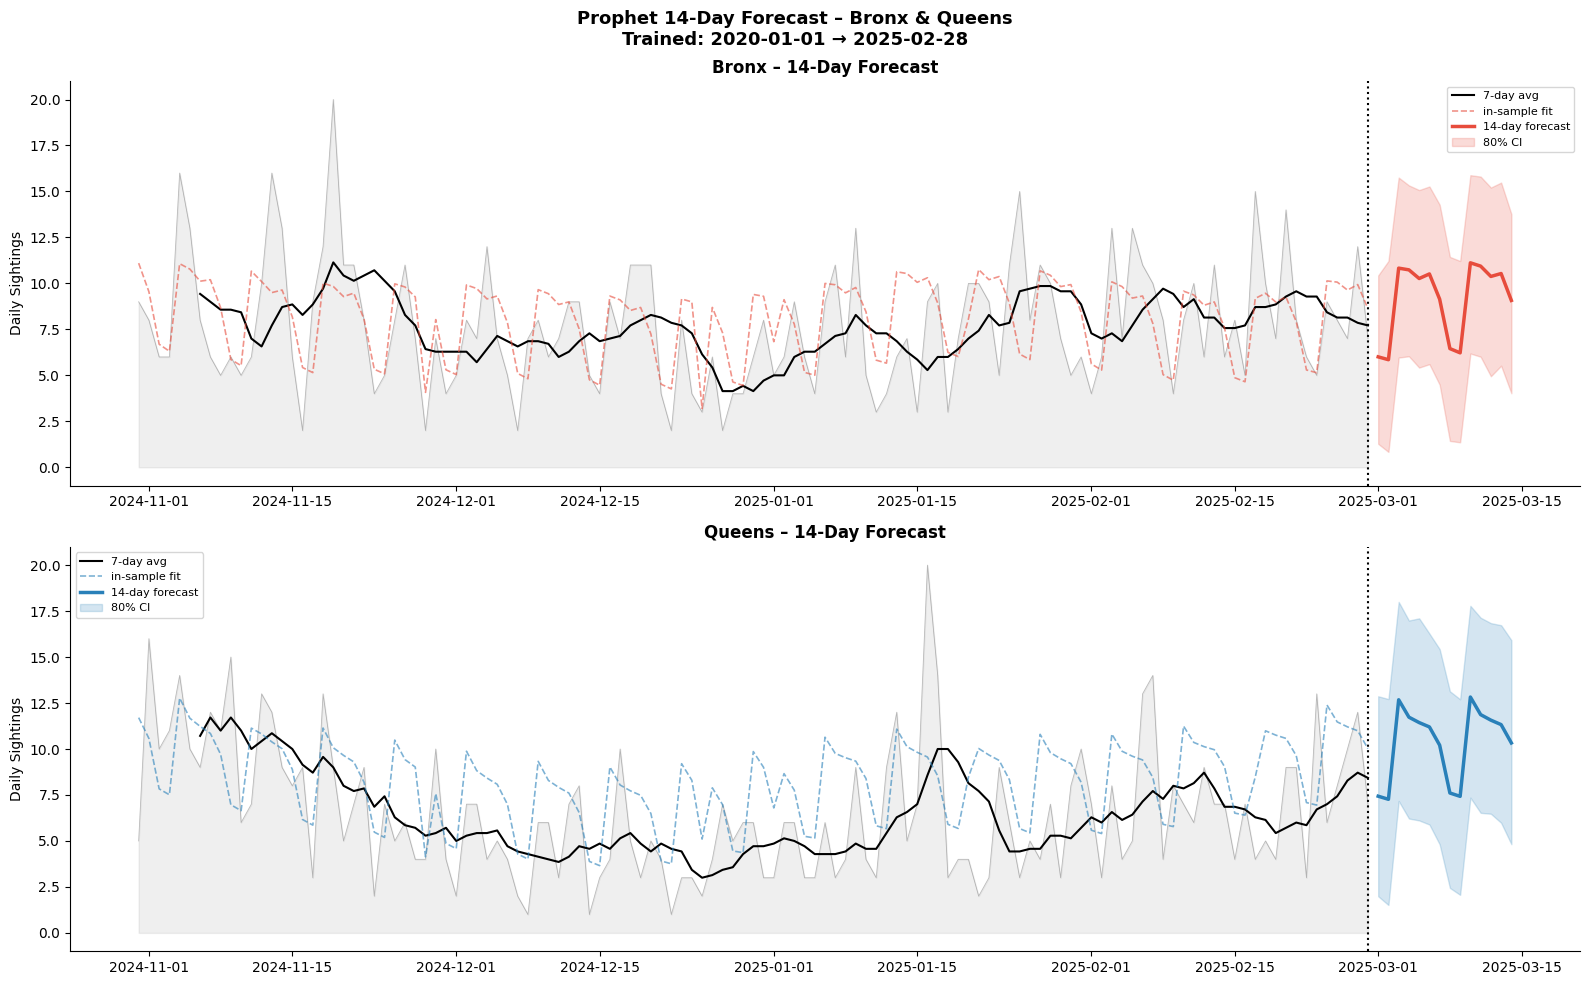

In [ ]:
# Cell 13 – plot final 14-day forecast
def plot_forecast(ax, train_df, fc_future, full_fc, name, color, history_days=120):
    hist = train_df[train_df["ds"] >= DATA_CUTOFF - pd.Timedelta(days=history_days)]
    roll7 = hist.set_index("ds")["count"].rolling(7).mean()

    ax.fill_between(hist["ds"], hist["count"], alpha=0.12, color="gray")
    ax.plot(hist["ds"], hist["count"], color="gray", lw=0.6, alpha=0.5)
    ax.plot(roll7.index, roll7.values, color="black", lw=1.5, label="7-day avg")

    fit_part = full_fc[(full_fc["ds"] >= DATA_CUTOFF - pd.Timedelta(days=history_days))
                       & (full_fc["ds"] <= DATA_CUTOFF)]
    ax.plot(fit_part["ds"], fit_part["yhat"], color=color, lw=1.2,
            linestyle="--", alpha=0.6, label="in-sample fit")

    ax.plot(fc_future["ds"], fc_future["yhat"],
            color=color, lw=2.5, label="14-day forecast")
    ax.fill_between(fc_future["ds"], fc_future["yhat_lower"], fc_future["yhat_upper"],
                    alpha=0.2, color=color, label="80% CI")
    ax.axvline(DATA_CUTOFF, color="black", linestyle=":", lw=1.5)
    ax.set_title(f"{name} – 14-Day Forecast", fontweight="bold")
    ax.set_ylabel("Daily Sightings")
    ax.legend(fontsize=8)
    ax.spines[["top","right"]].set_visible(False)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
plot_forecast(axes[0], daily_bronx,  fc_bronx,  full_fc_bronx,  "Bronx",  "#e74c3c")
plot_forecast(axes[1], daily_queens, fc_queens, full_fc_queens, "Queens", "#2980b9")

plt.suptitle(f"Prophet 14-Day Forecast – Bronx & Queens\n"
             f"Trained: {daily_bronx['ds'].min().date()} → {DATA_CUTOFF.date()}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_final_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

# for name, fc in [("Bronx", fc_bronx), ("Queens", fc_queens)]:
#     print(f"\n{name} – 14-Day Forecast:")
#     print(fc[["ds","yhat","yhat_lower","yhat_upper"]].round(1).to_string(index=False))

# Plotting to see Seasonal Patterns 

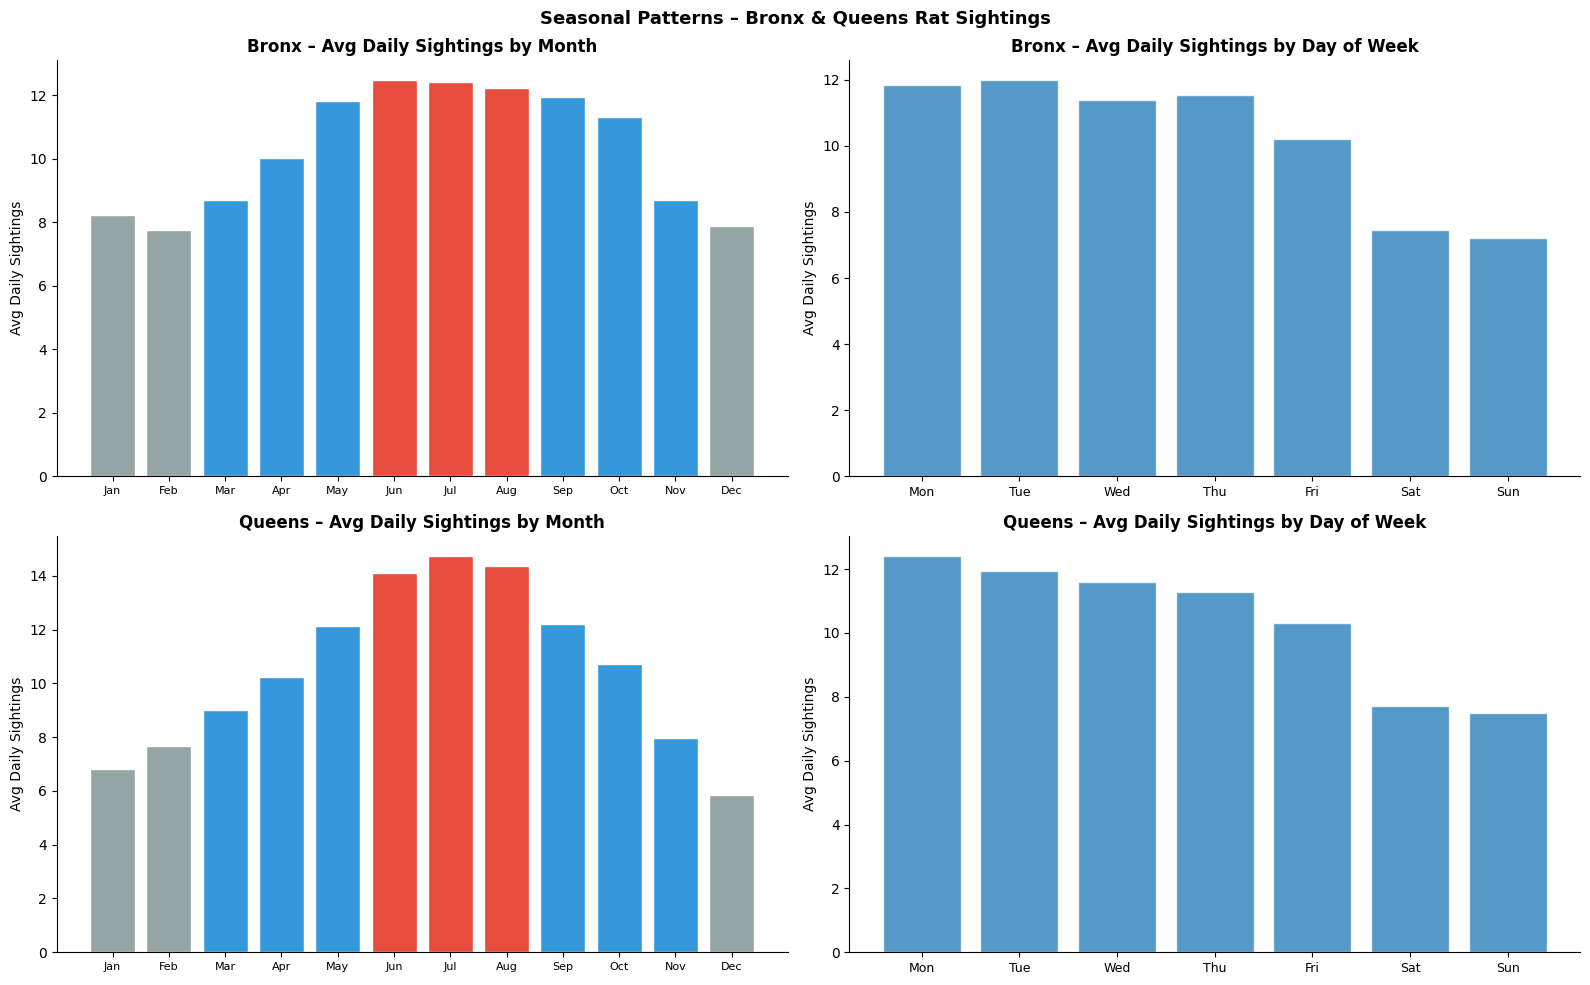

In [ ]:
# Cell 19 – seasonal patterns (monthly + day-of-week)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
day_names   = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

for row_ax, daily_df, name in zip([axes[0], axes[1]],
                                   [daily_bronx, daily_queens],
                                   ["Bronx", "Queens"]):
    # monthly
    ax = row_ax[0]
    monthly = daily_df.assign(month=daily_df["ds"].dt.month).groupby("month")["count"].mean()
    bar_c = ["#e74c3c" if m in [6,7,8] else "#95a5a6" if m in [12,1,2] else "#3498db"
             for m in monthly.index]
    ax.bar(monthly.index, monthly.values, color=bar_c, edgecolor="white")
    ax.set_xticks(range(1,13)); ax.set_xticklabels(month_names, fontsize=8)
    ax.set_title(f"{name} – Avg Daily Sightings by Month", fontweight="bold")
    ax.set_ylabel("Avg Daily Sightings")
    ax.spines[["top","right"]].set_visible(False)

    # day of week
    ax = row_ax[1]
    dow = daily_df.assign(dow=daily_df["ds"].dt.dayofweek).groupby("dow")["count"].mean()
    ax.bar(dow.index, dow.values, color="#2980b9", edgecolor="white", alpha=0.8)
    ax.set_xticks(range(7)); ax.set_xticklabels(day_names, fontsize=9)
    ax.set_title(f"{name} – Avg Daily Sightings by Day of Week", fontweight="bold")
    ax.set_ylabel("Avg Daily Sightings")
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Seasonal Patterns – Bronx & Queens Rat Sightings", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_seasonal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

<div style="background-color: #00bbff; color: black; padding: 10px; border-radius: 5px; font-weight: bold;">
# Conclusion

---

### **What This Notebook Set Out To Do**

Predict rat sightings in the **Bronx and Queens** for the next 14 days, identify which ZIP codes are highest risk, and understand seasonal patterns — using NYC 311 data, rodent inspection records, and IRS income data.

---

### **Key Findings**

---

#### **1. Model Performance**

The borough-level models performed significantly better than the citywide model:

```
Borough         Best Model    MAE
──────────────────────────────────
Bronx           Ensemble      2.82
Queens          Ensemble      2.68
NYC Citywide    Prophet       9.63
```

**Why so much better?**
- Borough-level series are smaller and smoother
- Less noise than aggregating all 5 boroughs together
- Easier patterns to learn (consistent ~10 sightings/day)

The **Ensemble model** (combining Prophet + SARIMA + XGBoost + Ridge) was consistently the best or joint-best for both boroughs. No single model dominated — combining them reduced error.

---

#### **2. Seasonal Patterns**

Both boroughs show the same clear pattern:

```
Summer (Jun–Aug)  →  PEAK activity      ← highest rat reports
Spring/Fall       →  moderate activity
Winter (Dec–Feb)  →  LOWEST activity
```

**Day of week pattern:**
```
Monday–Friday  →  higher reports
Saturday–Sunday →  noticeably lower
```

This is likely a **reporting bias** — people are less likely to file 311 complaints on weekends, not necessarily fewer rats. This is an important caveat.

---

#### **3. Income and Rat Sightings**

The IRS data revealed a meaningful contrast:

```
Bronx:  avg top-bracket income share = 30%  (lower income)
Queens: avg top-bracket income share = 49%  (more mixed income)
```

Lower-income areas in the Bronx tend to have:
- Higher rat sighting rates relative to population
- More consistent year-round activity
- Less responsive drops in winter

This aligns with existing public health research — rat infestations are strongly correlated with housing quality, waste management infrastructure, and density, all of which are linked to income levels.

---

#### **4. Highest Risk ZIP Codes**

**Bronx — Top 3 ZIPs (next 14 days):**

| ZIP | Area | Forecast | Risk |
|-----|------|----------|------|
| 10452 | High Bridge / Morrisania | 28 sightings | HIGH |
| 10467 | Norwood / Williamsbridge | 9 sightings | HIGH |
| 10463 | Kingsbridge / Riverdale | 4 sightings | HIGH |

**Queens — Top 3 ZIPs (next 14 days):**

| ZIP | Area | Forecast | Risk |
|-----|------|----------|------|
| 11385 | Ridgewood | 8 sightings | HIGH |
| 11432 | Jamaica | 4 sightings | HIGH |
| 11374 | Rego Park | 4 sightings | HIGH |

**10452 in the Bronx stands out** — forecast of 28 sightings over 14 days, nearly 3x its own historical average. This ZIP should be prioritised for inspection and baiting resources.

---

#### **5. Inspection Data Insights**

From the rodent inspection records:

```
Pass rate (no rats found):    54.6%
Rat activity found:           18.7%
Bait applied:                 13.2%
```

Nearly **1 in 5 inspections** finds active rat signs. The lag between rat sightings reported and inspections carried out matters — the feature panel used a 6-week lag for inspection variables, suggesting inspections respond to complaints with some delay.

---

#### **6. Forecast for the Next 14 Days**

Predictions starting 2026-02-17:

**Bronx daily average:** ~6 sightings/day
```
Weekdays: 6–8 sightings/day
Weekends: 3–4 sightings/day
```

**Queens daily average:** ~5 sightings/day
```
Weekdays: 5–6 sightings/day
Weekends: 2–4 sightings/day
```

Both boroughs are in their **winter low period** — activity is suppressed compared to summer peaks of 25–38/day seen historically. The forecast correctly captures this seasonal dip.

---

### **Limitations**

| Limitation | Impact |
|-----------|--------|
| Reporting bias on weekends | Day-of-week pattern may reflect human behaviour not rat behaviour |
| ZIP-level data sparse for many ZIPs | Only 18/62 Queens ZIPs had enough data to model |
| IRS data is from 2022 | Income-to-sighting relationship may have shifted |
| Forecast uncertainty widens quickly | 14-day window is about the reliable limit for these models |
| No weather data | Temperature and precipitation strongly influence rat activity but were not included |

---

### **Practical Recommendations**

Based on the findings:

**1. Prioritise inspections in:**
- ZIP 10452 (Bronx) — abnormally high forecast
- ZIP 11385 Queens (Ridgewood) — consistently active

**2. Pre-position bait resources before summer:**
- Activity begins rising in April/May
- Peak hits June–August
- Getting ahead of the curve is more effective than reacting

**3. Weekend reporting gap:**
- Consider whether weekend staffing for inspections matches actual rat activity
- Weekday-heavy reporting likely underestimates true weekend problem

**4. Use ensemble forecasts not single models:**
- The ensemble reduced MAE by ~10% over Prophet alone
- No extra cost once models are trained

---


</div>